<a href="https://colab.research.google.com/github/Sibitenda/Masters_MIS/blob/main/Data%20Analysis%20and%20Visualisation/week3_ML/creditcard_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

This notebook performs EDA, preprocessing, SMOTE oversampling, feature engineering, PCA, modeling (Logistic Regression, Decision Tree, Random Forest), and stratified cross-validation with evaluation (ROC-AUC, Precision-Recall, confusion matrices).

## 1) Setup & Data Loading

Run the cell below to install any missing packages and load the dataset `creditcard.csv`.

Make sure you have downloaded `creditcard.csv` from Kaggle (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) and uploaded it to the notebook environment or placed it in the same folder as this notebook.

In [2]:
# Install dependencies (uncomment if needed)
# !pip install pandas numpy matplotlib scikit-learn imbalanced-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print('Libraries imported successfully.')



Libraries imported successfully.


In [3]:
!pip install kaggle


In [4]:
from google.colab import files  # If you're in Colab
uploaded = files.upload()       # Or use the file upload gui in Jupyter

# Save the uploaded file into the required directory
import os, json
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "wb") as f:
    f.write(uploaded['kaggle.json'])

# Secure the file
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)


Saving kaggle.json to kaggle.json


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import zipfile
import os
from google.colab import files
# uploaded = files.upload()
# Define the path to the extracted CSV file
csv_path = '/content/drive/MyDrive/Colab Notebooks/creditcard.csv'

# Load the dataset
df = pd.read_csv(csv_path)

# Display the first few rows
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## 2) First EDA (Raw Data)

Compute descriptive statistics for `Amount` (mean, variance, skewness, kurtosis), plot histograms and boxplots for fraud vs non-fraud, and visualize class imbalance and correlation heatmap.

,count,mean,variance,skewness,kurtosis
overall,3972.0,65.000101,45662.639390,16.988085,480.158605
fraud=1,2.0,264.500000,139920.500000,NaN,NaN
fraud=0,3970.0,64.899597,45630.330057,17.013541,481.113678


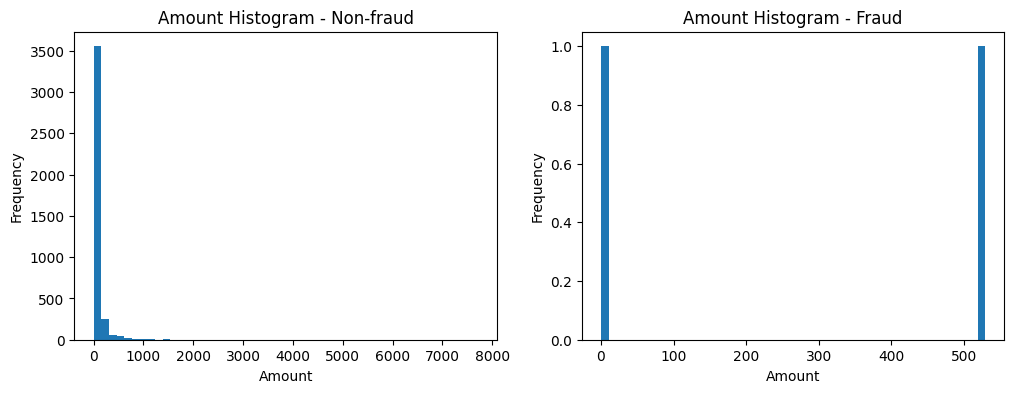

In [9]:
# Descriptive stats for Amount
def amount_stats(df):
    s = df['Amount']
    overall = pd.Series({
        'count': s.count(), 'mean': s.mean(), 'variance': s.var(), 'skewness': s.skew(), 'kurtosis': s.kurt()
    })
    fraud = pd.Series({
        'count': df.loc[df['Class']==1,'Amount'].count(),
        'mean': df.loc[df['Class']==1,'Amount'].mean(),
        'variance': df.loc[df['Class']==1,'Amount'].var(),
        'skewness': df.loc[df['Class']==1,'Amount'].skew(),
        'kurtosis': df.loc[df['Class']==1,'Amount'].kurt()
    })
    nonfraud = pd.Series({
        'count': df.loc[df['Class']==0,'Amount'].count(),
        'mean': df.loc[df['Class']==0,'Amount'].mean(),
        'variance': df.loc[df['Class']==0,'Amount'].var(),
        'skewness': df.loc[df['Class']==0,'Amount'].skew(),
        'kurtosis': df.loc[df['Class']==0,'Amount'].kurt()
    })
    return pd.DataFrame({'overall': overall, 'fraud=1': fraud, 'fraud=0': nonfraud})

if 'df' in globals():
    stats = amount_stats(df)
    display(stats.T)

    # Histograms
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].hist(df.loc[df['Class']==0,'Amount'].values, bins=50)
    axes[0].set_title('Amount Histogram - Non-fraud')
    axes[0].set_xlabel('Amount'); axes[0].set_ylabel('Frequency')
    axes[1].hist(df.loc[df['Class']==1,'Amount'].values, bins=50)
    axes[1].set_title('Amount Histogram - Fraud')
    axes[1].set_xlabel('Amount'); axes[1].set_ylabel('Frequency')
    plt.show()


else:
    print('Load the dataset first (see top cell).')

/tmp/ipython-input-1618691510.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df.loc[df['Class']==0,'Amount'].values, df.loc[df['Class']==1,'Amount'].values],


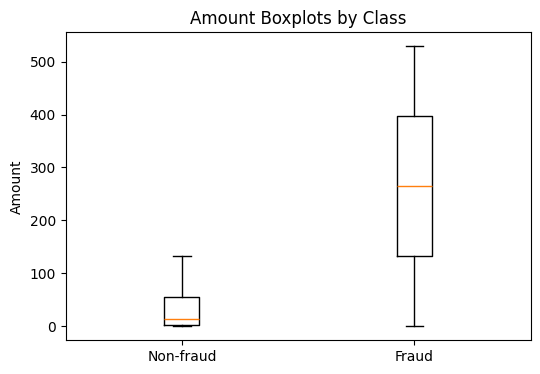

In [10]:
    # Boxplots
    plt.figure(figsize=(6,4))
    plt.boxplot([df.loc[df['Class']==0,'Amount'].values, df.loc[df['Class']==1,'Amount'].values],
                labels=['Non-fraud', 'Fraud'], showfliers=False)
    plt.title('Amount Boxplots by Class'); plt.ylabel('Amount'); plt.show()


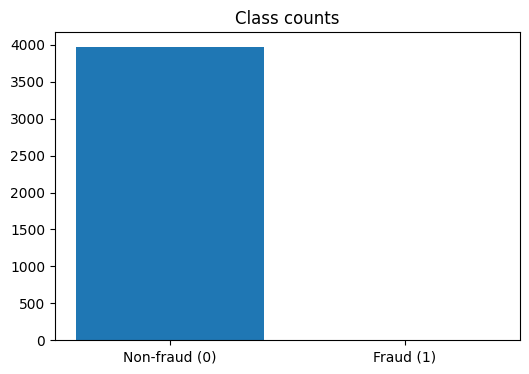

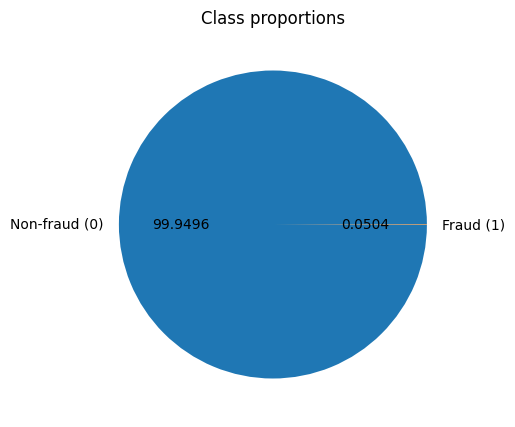

In [11]:

    # Class imbalance
    counts = df['Class'].value_counts().sort_index()
    plt.figure(figsize=(6,4)); plt.bar(['Non-fraud (0)','Fraud (1)'], counts.values); plt.title('Class counts'); plt.show()
    plt.figure(figsize=(5,5)); plt.pie(counts.values, labels=['Non-fraud (0)','Fraud (1)'], autopct='%1.4f'); plt.title('Class proportions'); plt.show()



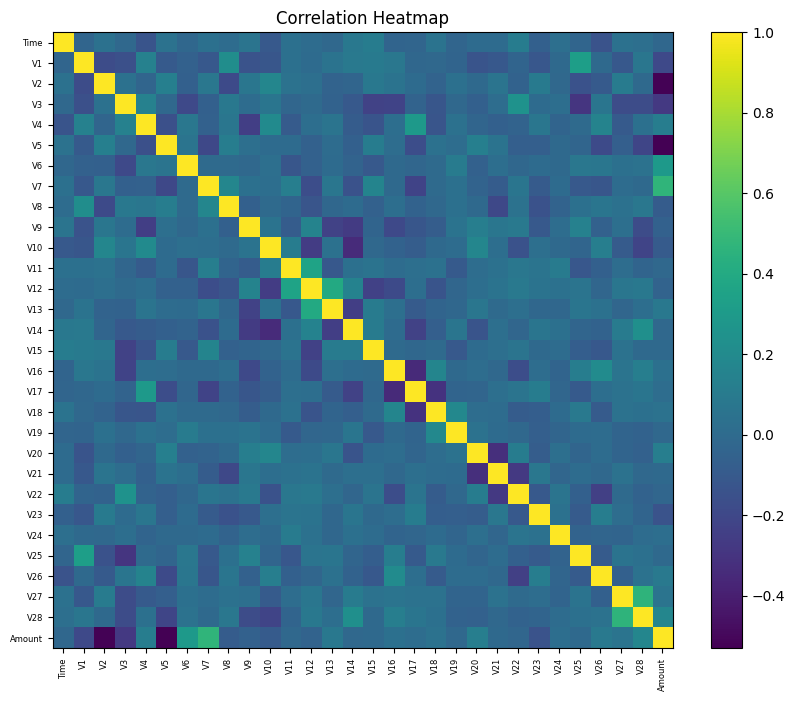

In [12]:
    # Correlation heatmap
    corr = df.drop(columns=['Class']).corr()
    plt.figure(figsize=(10,8))
    plt.imshow(corr.values, interpolation='nearest', aspect='auto')
    plt.colorbar(); plt.title('Correlation Heatmap')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
    plt.yticks(range(len(corr.columns)), corr.columns, fontsize=6)
    plt.show()

## 3) Feature Engineering & Preprocessing

Create `Hour` from `Time`, `Amount_log = log1p(Amount)`, and build a preprocessing pipeline (median imputation + scaling).

In [13]:
if 'df' in globals():
    df = df.copy()
    df['Hour'] = ((df['Time'] / 3600.0) % 24.0)
    df['Amount_log'] = np.log1p(df['Amount'].clip(lower=0))

    features = [f'V{i}' for i in range(1,29)] + ['Time','Amount','Hour','Amount_log']
    print('Feature count:', len(features))
    display(df[features].head())

    # Preprocessor
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, features)], remainder='drop')
else:
    print('Load the dataset first.')

Feature count: 32


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Time,Amount,Hour,Amount_log
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,149.62,0.000000,5.014760
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,2.69,0.000000,1.305626
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1,378.66,0.000278,5.939276
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1,123.50,0.000278,4.824306
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,2,69.99,0.000556,4.262539


## 4) Second EDA (Post-Processing)

PCA scatter (2 components) colored by fraud label and Random Forest feature importance (top 20).

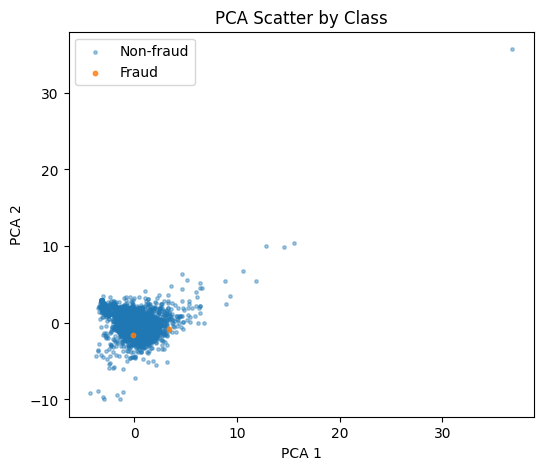

In [18]:
if 'df' in globals():
    # PCA scatter (standardize via preprocessor)
    X_proc = preprocessor.fit_transform(df)
    pca = PCA(n_components=2, random_state=42)
    comps = pca.fit_transform(X_proc)
    plt.figure(figsize=(6,5))
    mask0 = df['Class']==0; mask1 = df['Class']==1
    plt.scatter(comps[mask0,0], comps[mask0,1], s=6, alpha=0.4, label='Non-fraud')
    plt.scatter(comps[mask1,0], comps[mask1,1], s=10, alpha=0.8, label='Fraud')
    plt.xlabel('PCA 1'); plt.ylabel('PCA 2'); plt.legend(); plt.title('PCA Scatter by Class'); plt.show()

    # # RF feature importances (quick stratified split)
    # X = df[features].values
    # y = df['Class'].values
    # X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)
    # rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    # pipe = ImbPipeline(steps=[('pre', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', rf)])
    # pipe.fit(pd.DataFrame(X_train, columns=features), y_train)
    # importances = pipe.named_steps['clf'].feature_importances_
    # feat_series = pd.Series(importances, index=features).sort_values(ascending=False).head(20)
    # plt.figure(figsize=(8,6)); feat_series[::-1].plot(kind='barh'); plt.title('Top 20 Feature Importances'); plt.show()
else:
    print('Load the dataset first.')

## 5) Modeling & Evaluation

Train Logistic Regression, Decision Tree, and Random Forest using Stratified K-Fold CV with SMOTE inside each fold. Compute ROC-AUC, Average Precision (PR AUC), and select fold-wise thresholds that maximize F1. Plots for ROC and PR curves will be displayed.

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


[LogisticRegression | Fold 1] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[LogisticRegression | Fold 2] Skipping SMOTE (too few minority samples: 1)
[LogisticRegression | Fold 3] Skipping SMOTE (too few minority samples: 1)
[LogisticRegression | Fold 4] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[LogisticRegression | Fold 5] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


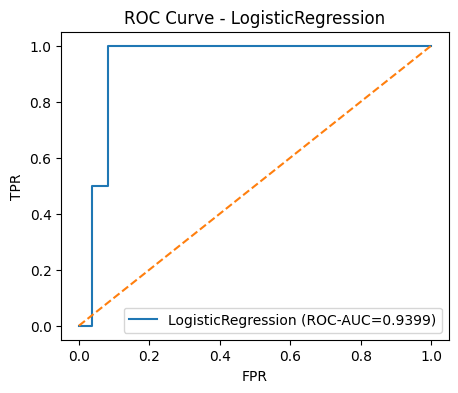

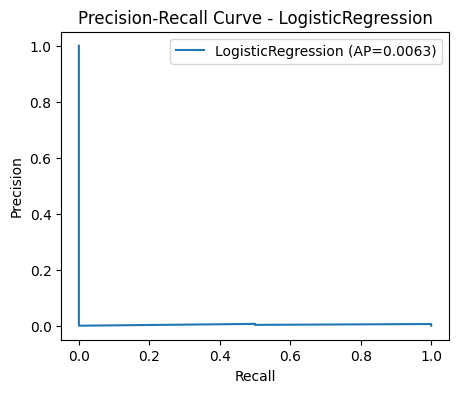

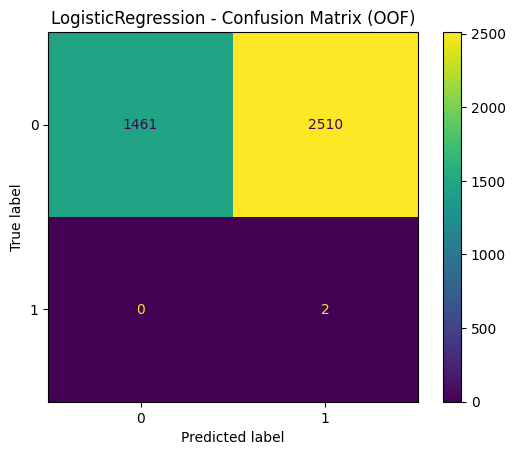

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[DecisionTree | Fold 1] Adjusting SMOTE k_neighbors=1 (minority=2)
[DecisionTree | Fold 2] Skipping SMOTE (too few minority samples: 1)
[DecisionTree | Fold 3] Skipping SMOTE (too few minority samples: 1)
[DecisionTree | Fold 4] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[DecisionTree | Fold 5] Adjusting SMOTE k_neighbors=1 (minority=2)


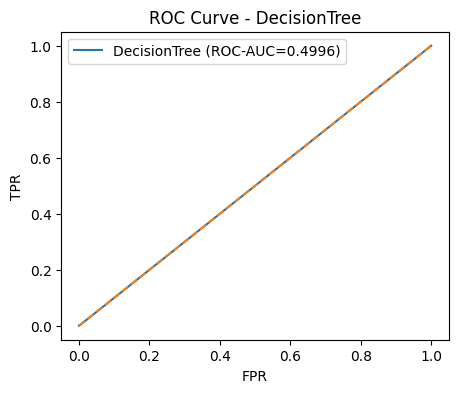

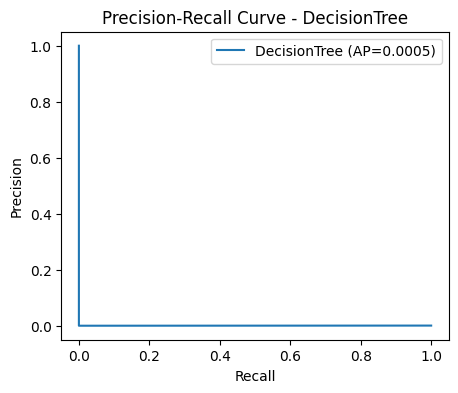

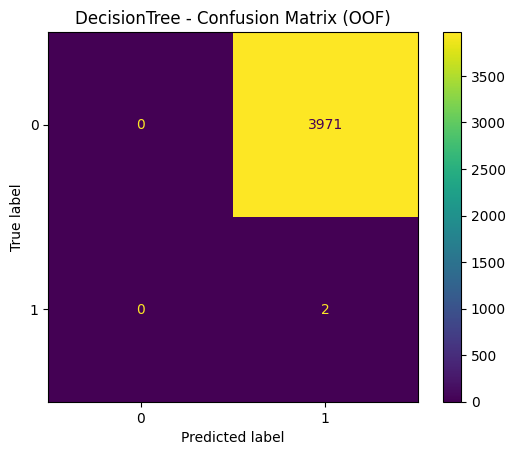

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


[RandomForest | Fold 1] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[RandomForest | Fold 2] Skipping SMOTE (too few minority samples: 1)
[RandomForest | Fold 3] Skipping SMOTE (too few minority samples: 1)
[RandomForest | Fold 4] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[RandomForest | Fold 5] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


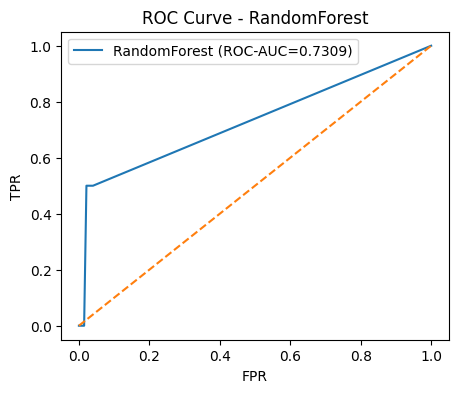

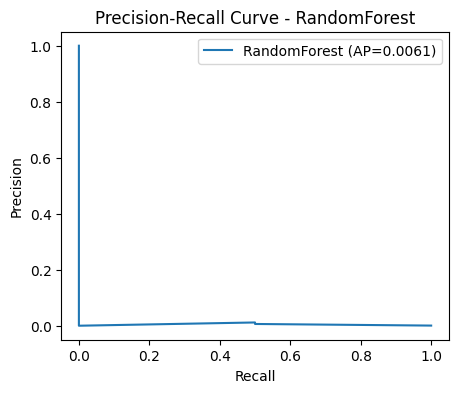

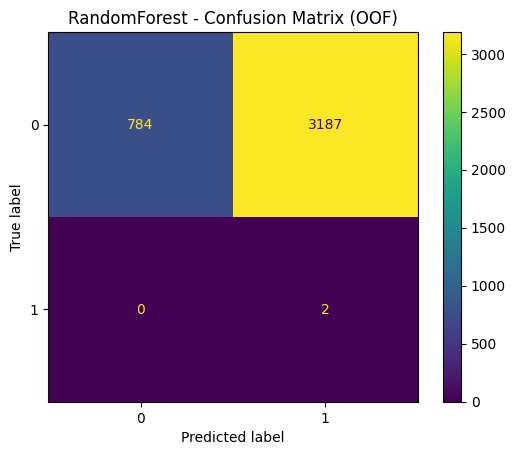

,model,roc_auc,avg_precision,f1,support_pos,support_neg
0,LogisticRegression,0.939940,0.006326,0.001591,2,3971
1,DecisionTree,0.499622,0.000503,0.001006,2,3971
2,RandomForest,0.730924,0.006066,0.001254,2,3971


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


def evaluate_models_cv(df, features, n_splits=5, random_state=42, verbose=True):
    """
    Evaluate multiple models with cross-validation, SMOTE handling, and plots.

    Parameters:
    -----------
    df : pd.DataFrame
        Dataset with features and a binary 'Class' column.
    features : list
        List of feature names.
    n_splits : int
        Number of StratifiedKFold splits.
    random_state : int
        Random seed.
    verbose : bool
        Print warnings when SMOTE is skipped or adjusted.
    """

    X = df[features].values
    y = df['Class'].values
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    models = {
        'LogisticRegression': LogisticRegression(max_iter=2000, solver='lbfgs', random_state=random_state),
        'DecisionTree': DecisionTreeClassifier(random_state=random_state),
        'RandomForest': RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1)
    }

    summary = []
    for name, clf in models.items():
        y_true_all, y_prob_all, y_pred_all = [], [], []

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            X_train = pd.DataFrame(X[train_idx], columns=features)
            y_train = y[train_idx]
            X_test = pd.DataFrame(X[test_idx], columns=features)
            y_test = y[test_idx]

            # ✅ Robust SMOTE handling
            n_minority = (y_train == 1).sum()
            if n_minority < 2:
                if verbose:
                    print(f"[{name} | Fold {fold}] Skipping SMOTE (too few minority samples: {n_minority})")
                steps = [('pre', preprocessor), ('clf', clf)]
            else:
                k_neighbors = min(5, n_minority - 1)
                if verbose and k_neighbors < 5:
                    print(f"[{name} | Fold {fold}] Adjusting SMOTE k_neighbors={k_neighbors} (minority={n_minority})")
                smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
                steps = [('pre', preprocessor), ('smote', smote), ('clf', clf)]

            pipe = ImbPipeline(steps=steps)
            pipe.fit(X_train, y_train)

            # Probabilities
            if hasattr(pipe.named_steps['clf'], 'predict_proba'):
                probs = pipe.predict_proba(X_test)[:, 1]
            else:
                probs = pipe.decision_function(X_test)
                probs = (probs - probs.min()) / (probs.max() - probs.min() + 1e-12)

            # threshold that maximizes F1
            precision, recall, thresholds = precision_recall_curve(y_test, probs)
            f1s = 2 * (precision * recall) / (precision + recall + 1e-12)
            best_idx = np.nanargmax(f1s)
            best_thr = 0.5 if best_idx >= len(thresholds) else thresholds[best_idx]
            preds = (probs >= best_thr).astype(int)

            y_true_all.append(y_test)
            y_prob_all.append(probs)
            y_pred_all.append(preds)

        # Concatenate results across folds
        y_true_all = np.concatenate(y_true_all)
        y_prob_all = np.concatenate(y_prob_all)
        y_pred_all = np.concatenate(y_pred_all)

        # Metrics
        roc_auc = roc_auc_score(y_true_all, y_prob_all)
        ap = average_precision_score(y_true_all, y_prob_all)
        f1 = f1_score(y_true_all, y_pred_all, zero_division=0)

        # ROC curve
        fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f'{name} (ROC-AUC={roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], '--')
        plt.xlabel('FPR'); plt.ylabel('TPR')
        plt.title(f'ROC Curve - {name}')
        plt.legend(); plt.show()

        # PR curve
        pr_prec, pr_rec, _ = precision_recall_curve(y_true_all, y_prob_all)
        plt.figure(figsize=(5, 4))
        plt.plot(pr_rec, pr_prec, label=f'{name} (AP={ap:.4f})')
        plt.xlabel('Recall'); plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve - {name}')
        plt.legend(); plt.show()

        # Confusion Matrix
        cm = confusion_matrix(y_true_all, y_pred_all)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot(values_format='d')
        plt.title(f'{name} - Confusion Matrix (OOF)')
        plt.show()

        summary.append({
            'model': name,
            'roc_auc': roc_auc,
            'avg_precision': ap,
            'f1': f1,
            'support_pos': int((y_true_all == 1).sum()),
            'support_neg': int((y_true_all == 0).sum())
        })

    return pd.DataFrame(summary)


# Example call (assuming df and features exist):
if 'df' in globals():
    summary_df = evaluate_models_cv(df, features, n_splits=5)
    display(summary_df)
else:
    print("Load the dataset first.")


🔹 Oversampling (SMOTE)
[LogisticRegression | Fold 1] Adjusting SMOTE k_neighbors=1 (minority=2)
[LogisticRegression | Fold 2] Skipping SMOTE (too few minority samples: 1)
[LogisticRegression | Fold 3] Skipping SMOTE (too few minority samples: 1)
[LogisticRegression | Fold 4] Adjusting SMOTE k_neighbors=1 (minority=2)
[LogisticRegression | Fold 5] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


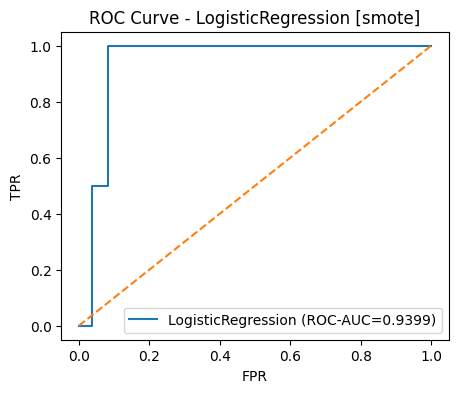

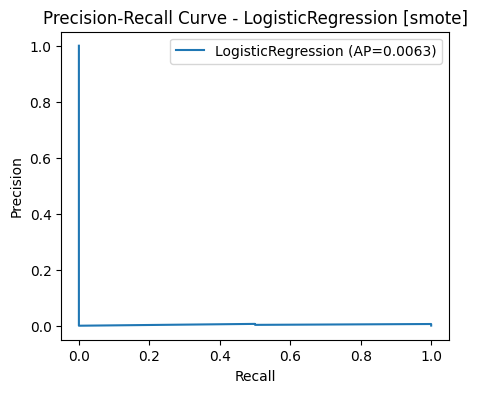

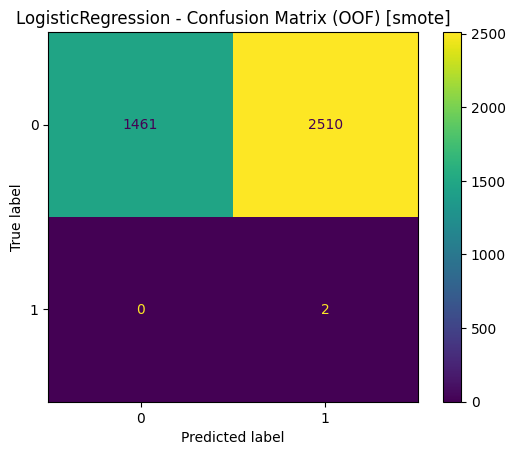

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[DecisionTree | Fold 1] Adjusting SMOTE k_neighbors=1 (minority=2)
[DecisionTree | Fold 2] Skipping SMOTE (too few minority samples: 1)
[DecisionTree | Fold 3] Skipping SMOTE (too few minority samples: 1)
[DecisionTree | Fold 4] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[DecisionTree | Fold 5] Adjusting SMOTE k_neighbors=1 (minority=2)


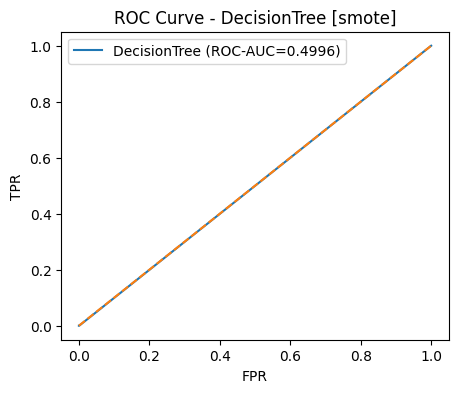

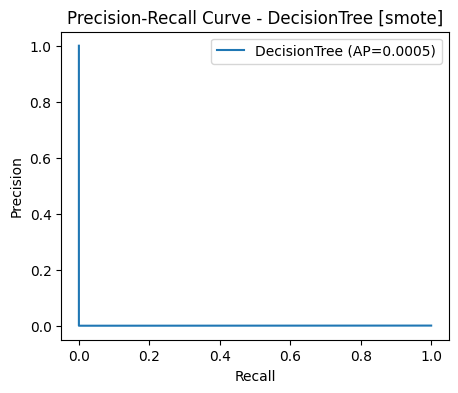

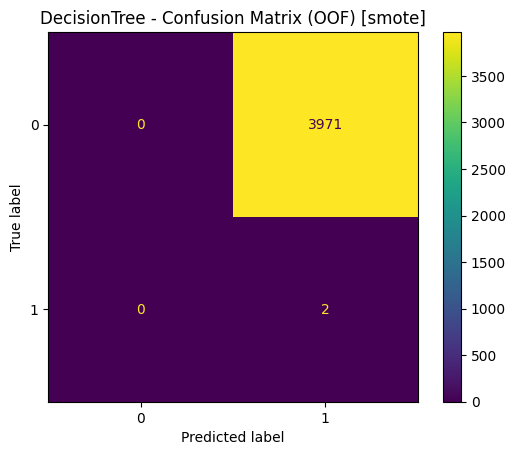

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


[RandomForest | Fold 1] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[RandomForest | Fold 2] Skipping SMOTE (too few minority samples: 1)
[RandomForest | Fold 3] Skipping SMOTE (too few minority samples: 1)
[RandomForest | Fold 4] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[RandomForest | Fold 5] Adjusting SMOTE k_neighbors=1 (minority=2)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


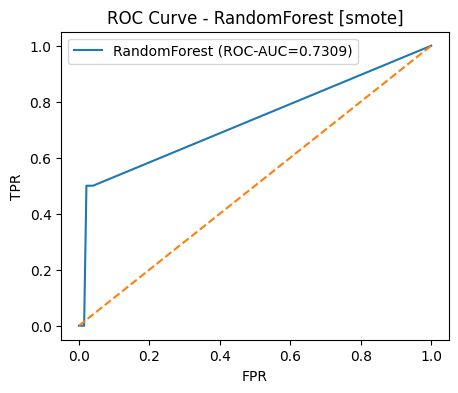

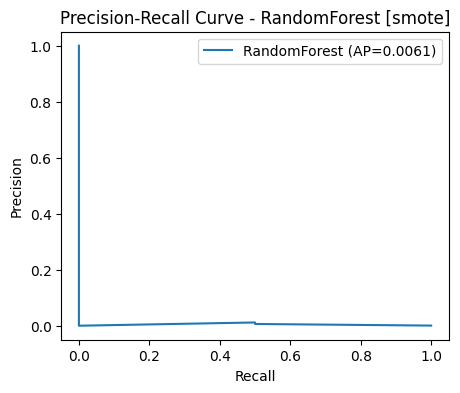

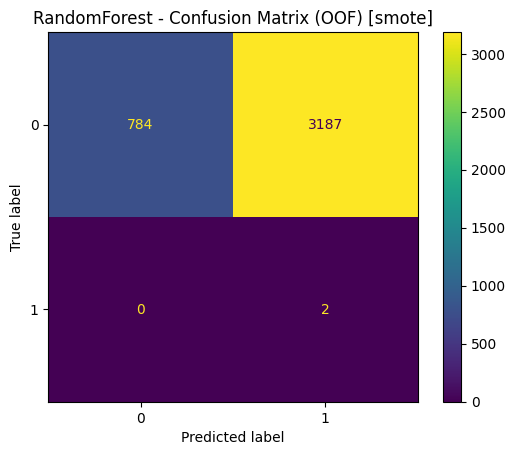

,model,roc_auc,avg_precision,f1,support_pos,support_neg
0,LogisticRegression,0.939940,0.006326,0.001591,2,3971
1,DecisionTree,0.499622,0.000503,0.001006,2,3971
2,RandomForest,0.730924,0.006066,0.001254,2,3971


🔹 Undersampling (RandomUnderSampler)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


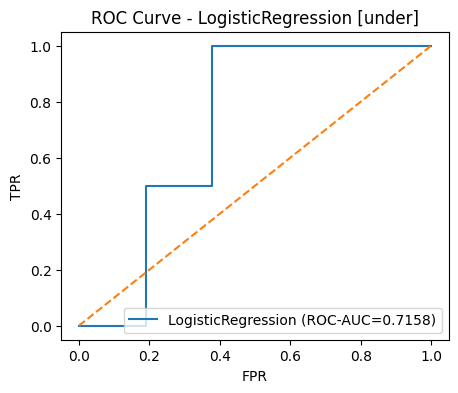

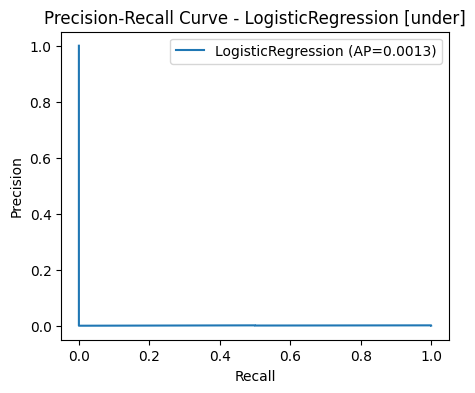

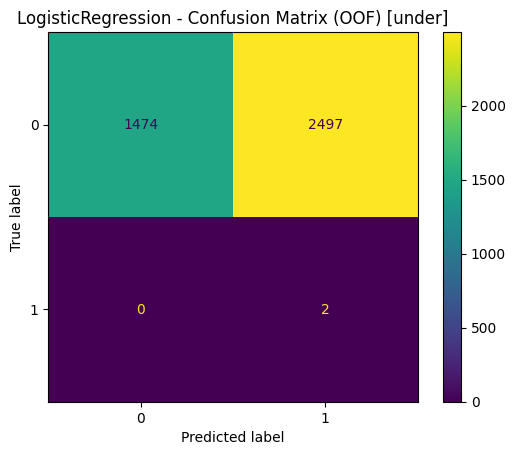

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


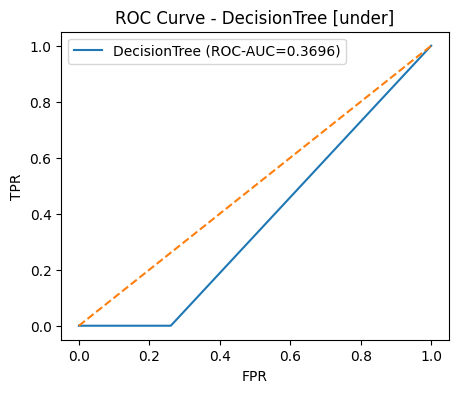

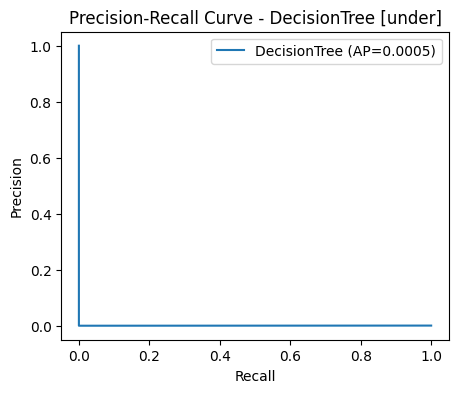

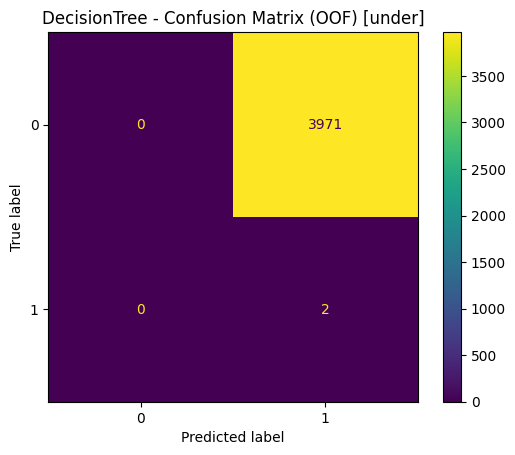

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


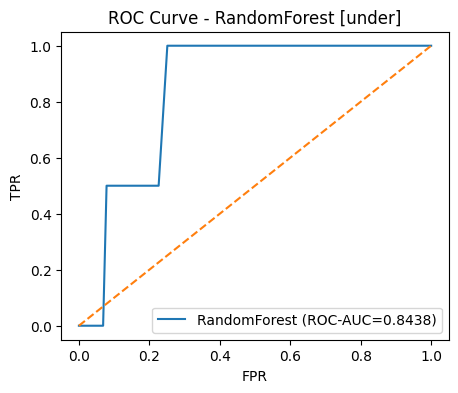

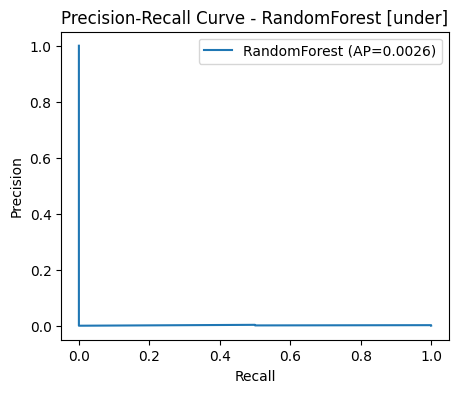

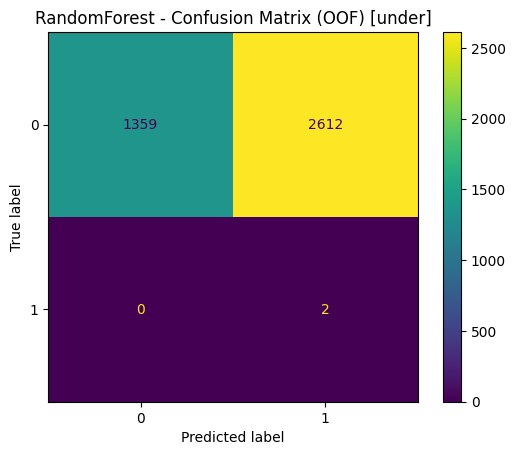

,model,roc_auc,avg_precision,f1,support_pos,support_neg
0,LogisticRegression,0.715815,0.001324,0.001599,2,3971
1,DecisionTree,0.369554,0.000503,0.001006,2,3971
2,RandomForest,0.843805,0.002598,0.001529,2,3971


🔹 Hybrid (SMOTEENN)
[LogisticRegression | Fold 1] Adjusting SMOTEENN with SMOTE(k_neighbors=1)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[LogisticRegression | Fold 2] Skipping SMOTEENN (too few minority samples: 1)
[LogisticRegression | Fold 3] Skipping SMOTEENN (too few minority samples: 1)
[LogisticRegression | Fold 4] Adjusting SMOTEENN with SMOTE(k_neighbors=1)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[LogisticRegression | Fold 5] Adjusting SMOTEENN with SMOTE(k_neighbors=1)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


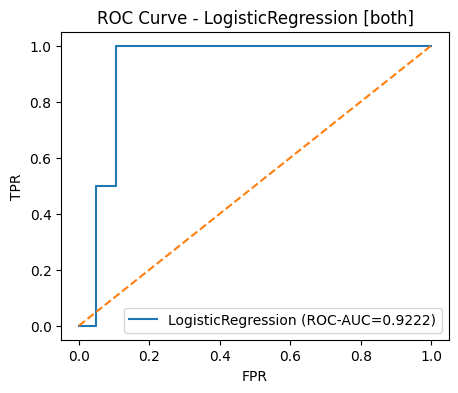

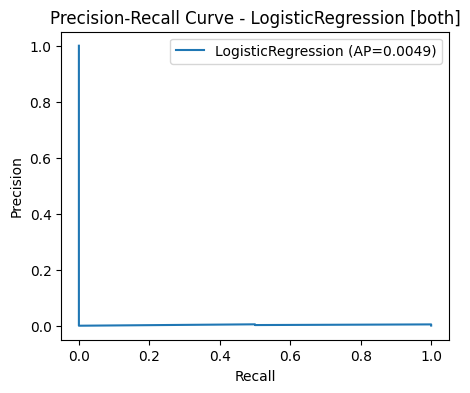

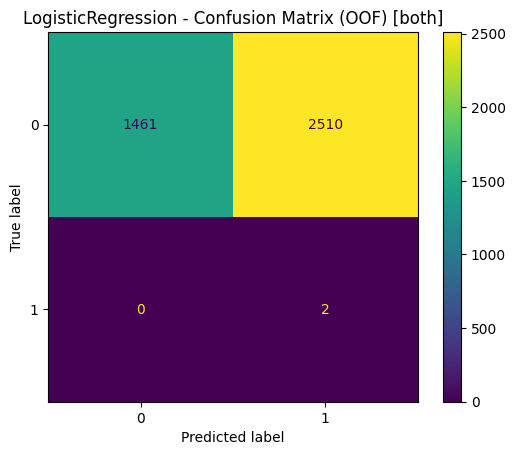

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


[DecisionTree | Fold 1] Adjusting SMOTEENN with SMOTE(k_neighbors=1)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[DecisionTree | Fold 2] Skipping SMOTEENN (too few minority samples: 1)
[DecisionTree | Fold 3] Skipping SMOTEENN (too few minority samples: 1)
[DecisionTree | Fold 4] Adjusting SMOTEENN with SMOTE(k_neighbors=1)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[DecisionTree | Fold 5] Adjusting SMOTEENN with SMOTE(k_neighbors=1)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


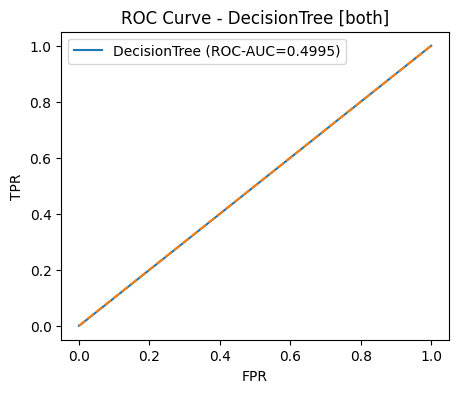

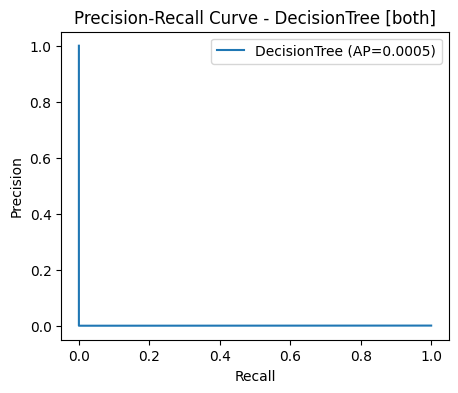

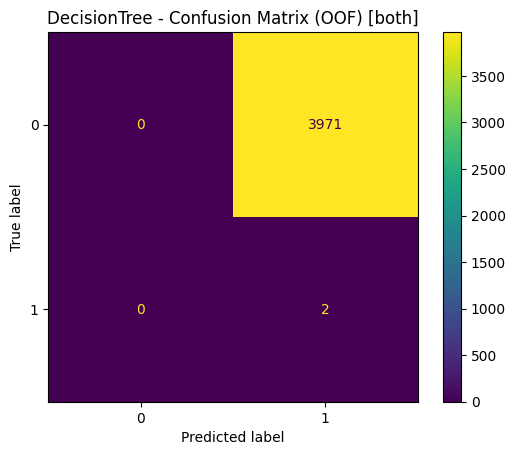

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


[RandomForest | Fold 1] Adjusting SMOTEENN with SMOTE(k_neighbors=1)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[RandomForest | Fold 2] Skipping SMOTEENN (too few minority samples: 1)
[RandomForest | Fold 3] Skipping SMOTEENN (too few minority samples: 1)
[RandomForest | Fold 4] Adjusting SMOTEENN with SMOTE(k_neighbors=1)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


[RandomForest | Fold 5] Adjusting SMOTEENN with SMOTE(k_neighbors=1)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


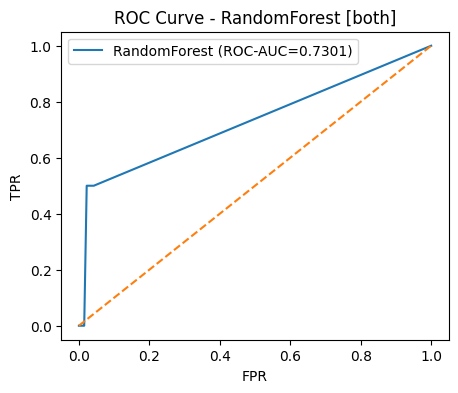

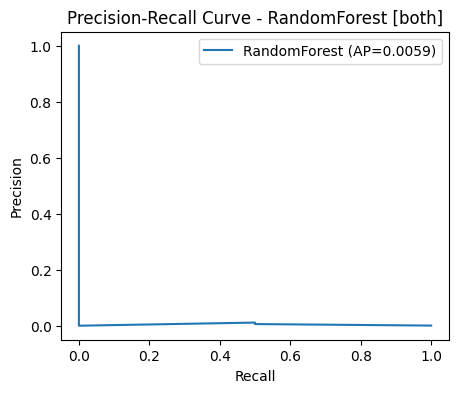

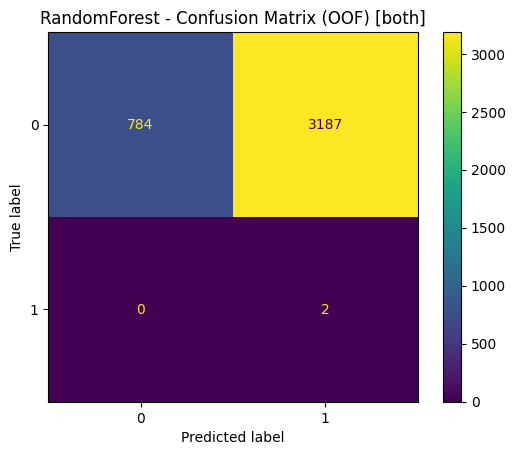

,model,roc_auc,avg_precision,f1,support_pos,support_neg
0,LogisticRegression,0.922186,0.004882,0.001591,2,3971
1,DecisionTree,0.499496,0.000503,0.001006,2,3971
2,RandomForest,0.730106,0.005870,0.001254,2,3971


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN


def evaluate_models_cv(df, features, n_splits=5, random_state=42, sampling="smote", verbose=True):
    """
    Evaluate LogisticRegression, DecisionTree, RandomForest with CV.
    Supports oversampling (SMOTE), undersampling (RandomUnderSampler),
    hybrid (SMOTEENN), or no sampling.

    Parameters:
    -----------
    df : pd.DataFrame
        Dataset with features and a binary 'Class' column.
    features : list
        List of feature names.
    n_splits : int
        Number of StratifiedKFold splits.
    random_state : int
        Random seed.
    sampling : str or None
        "smote", "under", "both", or None.
    verbose : bool
        Print warnings when adjustments are made.
    """

    X = df[features].values
    y = df['Class'].values
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    models = {
        'LogisticRegression': LogisticRegression(max_iter=2000, solver='lbfgs', random_state=random_state),
        'DecisionTree': DecisionTreeClassifier(random_state=random_state),
        'RandomForest': RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1)
    }

    summary = []
    for name, clf in models.items():
        y_true_all, y_prob_all, y_pred_all = [], [], []

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            X_train = pd.DataFrame(X[train_idx], columns=features)
            y_train = y[train_idx]
            X_test = pd.DataFrame(X[test_idx], columns=features)
            y_test = y[test_idx]

            # 🔹 Choose resampling strategy
            sampler = None
            if sampling == "smote":
                n_minority = (y_train == 1).sum()
                if n_minority < 2:
                    if verbose:
                        print(f"[{name} | Fold {fold}] Skipping SMOTE (too few minority samples: {n_minority})")
                else:
                    k_neighbors = min(5, n_minority - 1)
                    if verbose and k_neighbors < 5:
                        print(f"[{name} | Fold {fold}] Adjusting SMOTE k_neighbors={k_neighbors} (minority={n_minority})")
                    sampler = SMOTE(random_state=random_state, k_neighbors=k_neighbors)

            elif sampling == "under":
                sampler = RandomUnderSampler(random_state=random_state)

            elif sampling == "both":
              n_minority = (y_train == 1).sum()

              if n_minority < 2:
                  if verbose:
                      print(f"[{name} | Fold {fold}] Skipping SMOTEENN (too few minority samples: {n_minority})")
                  sampler = None
              else:
                  k_neighbors = min(5, n_minority - 1)
                  if verbose and k_neighbors < 5:
                      print(f"[{name} | Fold {fold}] Adjusting SMOTEENN with SMOTE(k_neighbors={k_neighbors})")
                  sampler = SMOTEENN(random_state=random_state,
                                    smote=SMOTE(random_state=random_state, k_neighbors=k_neighbors))


            # Build pipeline
            if sampler is None:
                steps = [('pre', preprocessor), ('clf', clf)]
            else:
                steps = [('pre', preprocessor), ('balance', sampler), ('clf', clf)]

            pipe = ImbPipeline(steps=steps)
            pipe.fit(X_train, y_train)

            # Probabilities
            if hasattr(pipe.named_steps['clf'], 'predict_proba'):
                probs = pipe.predict_proba(X_test)[:, 1]
            else:
                probs = pipe.decision_function(X_test)
                probs = (probs - probs.min()) / (probs.max() - probs.min() + 1e-12)

            # threshold that maximizes F1
            precision, recall, thresholds = precision_recall_curve(y_test, probs)
            f1s = 2 * (precision * recall) / (precision + recall + 1e-12)
            best_idx = np.nanargmax(f1s)
            best_thr = 0.5 if best_idx >= len(thresholds) else thresholds[best_idx]
            preds = (probs >= best_thr).astype(int)

            y_true_all.append(y_test)
            y_prob_all.append(probs)
            y_pred_all.append(preds)

        # Concatenate results across folds
        y_true_all = np.concatenate(y_true_all)
        y_prob_all = np.concatenate(y_prob_all)
        y_pred_all = np.concatenate(y_pred_all)

        # Metrics
        roc_auc = roc_auc_score(y_true_all, y_prob_all)
        ap = average_precision_score(y_true_all, y_prob_all)
        f1 = f1_score(y_true_all, y_pred_all, zero_division=0)

        # ROC curve
        fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f'{name} (ROC-AUC={roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], '--')
        plt.xlabel('FPR'); plt.ylabel('TPR')
        plt.title(f'ROC Curve - {name} [{sampling}]')
        plt.legend(); plt.show()

        # PR curve
        pr_prec, pr_rec, _ = precision_recall_curve(y_true_all, y_prob_all)
        plt.figure(figsize=(5, 4))
        plt.plot(pr_rec, pr_prec, label=f'{name} (AP={ap:.4f})')
        plt.xlabel('Recall'); plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve - {name} [{sampling}]')
        plt.legend(); plt.show()

        # Confusion Matrix
        cm = confusion_matrix(y_true_all, y_pred_all)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot(values_format='d')
        plt.title(f'{name} - Confusion Matrix (OOF) [{sampling}]')
        plt.show()

        summary.append({
            'model': name,
            'roc_auc': roc_auc,
            'avg_precision': ap,
            'f1': f1,
            'support_pos': int((y_true_all == 1).sum()),
            'support_neg': int((y_true_all == 0).sum())
        })

    return pd.DataFrame(summary)


# Example usage:
if 'df' in globals():
    print("🔹 Oversampling (SMOTE)")
    smote_results = evaluate_models_cv(df, features, n_splits=5, sampling="smote")
    display(smote_results)

    print("🔹 Undersampling (RandomUnderSampler)")
    under_results = evaluate_models_cv(df, features, n_splits=5, sampling="under")
    display(under_results)

    print("🔹 Hybrid (SMOTEENN)")
    both_results = evaluate_models_cv(df, features, n_splits=5, sampling="both")
    display(both_results)
else:
    print("Load the dataset first.")


## 6) Interpretation & Ethical Considerations

- Compare ROC-AUC, PR-AUC (Average Precision), and F1 across models.
- In highly imbalanced fraud detection, PR curves / Average Precision are more informative than ROC-AUC.
- False negatives (missed fraud) have direct financial and reputational costs — consider favoring recall via threshold tuning or cost-sensitive methods.
- Operational workflow: prefer higher recall (catch more fraud) then have analysts triage alerts to control false-positive costs.